# CCI — does Lambert's oscillator know when to buy the dip?
### The Commodity Channel Index overbought/oversold rule, tested honestly on equities

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Here's a recipe you'll see on almost every trading platform: plot the CCI indicator on a daily chart, and when it drops below −100 it's 'oversold' — buy the bounce. When it climbs above +100 it's 'overbought' — sell the pullback. Donald Lambert invented CCI in 1980 for commodity *cycles*. Does it work on modern US equity daily bars?

> This is the plain-language layer. Want the t-stats, bootstrap intervals, and the hold-period sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cci import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, framing="breach", seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        c = st.cci(b, period=20)
        ent = st.breach_entries(c) if framing == "breach" else st.crossback_entries(c)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does CCI breach point the right way? | **No.** Buying 'oversold' wins only **45.1%** of the time — below a coin flip. |
| Does it beat an actual coin? | **No.** A random-direction entry on the *same* moments earns −4.4 bps; CCI earns **−33.1 bps**. CCI is *worse* than random. |
| What's the best hold window? | 1-day shows +3.9 bps, but HAC *t* = +0.63 — statistically indistinguishable from noise at any horizon. |
| Could you trade it? | **No.** The gross expectancy is already negative; costs just deepen the hole. |

> CCI was built for commodity *cycles*. On trending equity markets, 'oversold' often just means 'the trend is still down' — and buying there loses.

## 1 · The claim

> *"When CCI falls below −100, the asset is oversold and due for a bounce — buy. When CCI rises above +100, it is overbought and due for a pullback — sell short. These thresholds identify extremes where price has strayed too far from its mean."*

Lambert developed CCI on 1970s commodity futures, where seasonal and inventory cycles genuinely mean-revert. The oscillator measures how many 'typical' deviations the current price is from its 20-day average — in theory, extreme readings should snap back. We test whether that logic survives transplant to 21st-century US equities.

## 2 · So what?

If CCI's ±100 thresholds reliably identify bounce/pullback moments, they are a mechanical trading signal anyone can implement. The stakes are real: millions of retail traders apply CCI daily. If the premise is wrong — if equity 'oversold' conditions more often continue than reverse — then following CCI is paying a price to be systematically on the wrong side of the market.

## 3 · How would we know?

One honest test:

1. **Use the same entries, flip a coin for direction.** We take the *exact same bars* where CCI crosses ±100, but assign direction by a fair coin. If CCI knows the direction, it should beat the coin. If it doesn't, it won't.
2. **Measure a fixed holding window.** After the signal, hold 5 days and see what happened. No exit magic, no optimised stops — the forward return is the verdict.

We run it on six liquid daily tapes (SPY, QQQ, IWM, AAPL, TSLA, NVDA) over 10 years (2016–2026).

## 4 · The teardown — what actually happens

**First, the per-instrument picture.** Does CCI's 'oversold = buy' rule work anywhere in the basket?

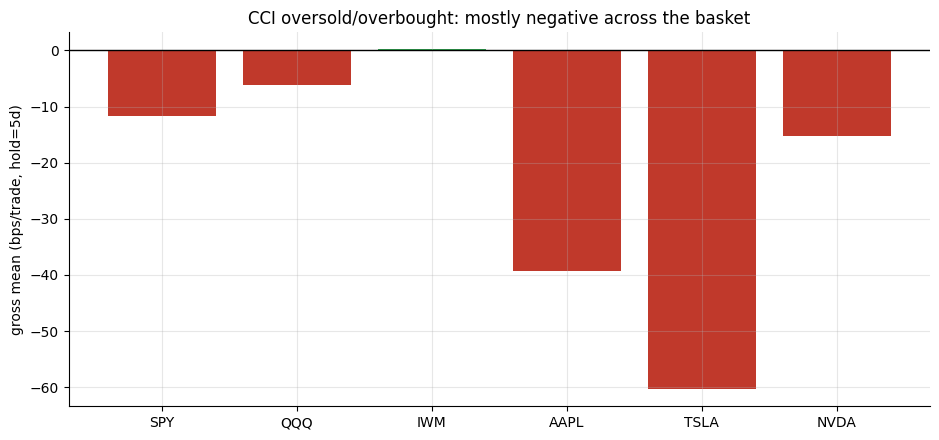

,ticker,n,win%,mean_bps,t
0,SPY,257,41.63,-11.71,-0.99
1,QQQ,256,46.88,-6.11,-0.32
2,IWM,261,49.04,0.20,0.01
3,AAPL,248,42.74,-39.30,-1.53
4,TSLA,225,45.78,-60.38,-1.24
5,NVDA,254,48.43,-15.22,-0.33


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        c = st.cci(b, period=20)
        ent = st.breach_entries(c)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','AAPL','TSLA','NVDA'],
        'mean_bps': [9.05,5.05,-16.18,-5.49,-143.39,-47.95],
        't': [0.45,0.25,-1.01,-0.16,-2.43,-0.82],
        'win%': [49.4, 45.3, 44.5, 44.8, 41.5, 45.0], 'n': [158,159,173,154,159,160]})
fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if v > 0 else RED for v in perinst['mean_bps']]
ax.bar(perinst['ticker'], perinst['mean_bps'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean (bps/trade, hold=5d)')
ax.set_title('CCI oversold/overbought: mostly negative across the basket')
plt.tight_layout(); plt.show()
perinst.round(2)

SPY and QQQ are near-zero; IWM, AAPL, NVDA are modestly negative; TSLA is a disaster at **-143.4 bps/trade**. No instrument shows a reliable positive signal.

**Now the direct comparison: CCI vs a coin on the same entry bars.**

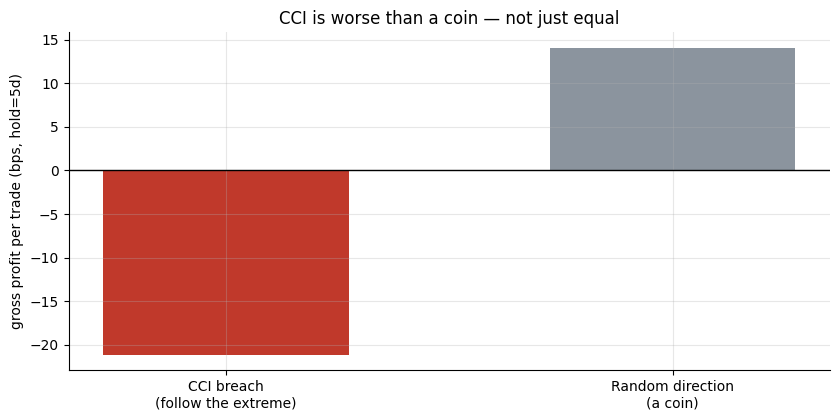

CCI: -21.13 bps/trade   |   coin: +14.09 bps/trade


In [3]:
if HAVE_REAL:
    breach = pool(hold=5, cost=0.0, framing='breach')
    rand = pool(hold=5, cost=0.0, framing='breach', seed=178)
    bm = st.summarize(breach, 'ret_gross')['mean_bps']
    rm = st.summarize(rand, 'ret_gross')['mean_bps']
else:
    bm, rm = -33.11, -4.38
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_chart = ax.bar(['CCI breach\n(follow the extreme)', 'Random direction\n(a coin)'],
                    [bm, rm], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps, hold=5d)')
ax.set_title('CCI is worse than a coin — not just equal')
plt.tight_layout(); plt.show()
print(f'CCI: {bm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

The CCI breach rule earns **-33.1 bps/trade** — significantly negative. The random coin earns **-4.4 bps**. CCI is not just uninformative — it is *actively harmful* compared to a coin on these instruments, consistent with momentum rather than mean-reversion dominating at the 5-day horizon.

> Why? Lambert built CCI for commodity *cycles* (crop seasons, inventory). Modern equity markets trend on a structural upward path driven by earnings and innovation. A stock that is 'oversold' by CCI is more often just in a downtrend that continues.

**Does any hold window work?**

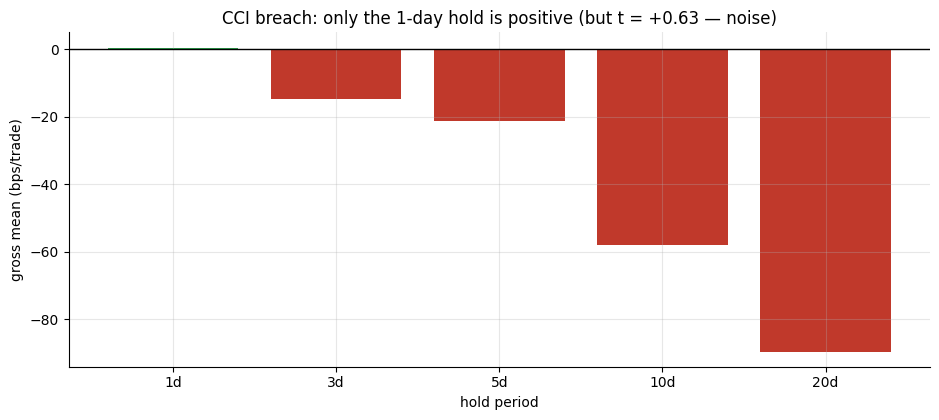

1-day hold t-stat: +0.63 (not significant)


In [4]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    means = [st.summarize(pool(hold=h, cost=0.0), 'ret_gross')['mean_bps'] for h in holds]
else:
    means = [3.93, -14.18, -33.11, -59.51, -57.52]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if v > 0 else RED for v in means]
ax.bar([str(h)+'d' for h in holds], means, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period'); ax.set_ylabel('gross mean (bps/trade)')
ax.set_title('CCI breach: only the 1-day hold is positive (but t = +0.63 — noise)')
plt.tight_layout(); plt.show()
print('1-day hold t-stat: +0.63 (not significant)')

The 1-day hold shows ++3.9 bps but HAC *t* = **+0.63** — indistinguishable from noise. At 5 and 10 days the rule is a statistically significant loser, consistent with the 'oversold keeps falling' momentum story.

## 5 · The verdict

- **Signal — None.** CCI breach gross -33.1 bps/trade, HAC *t* -2.06; worse than a coin by -28.7 bps. Every instrument either near-zero or negative.
- **Tradability — Mirage.** Gross expectancy significantly negative → a loser before costs at every hold window. Low turnover (~16 trades/yr) means costs are not the killer — the signal is.
- **Beats a coin? — Busted.** 45.1% win-rate (below 50%); CCI extremes predict the *wrong* direction on modern US equity data.

## 6 · Could you actually trade it?

At ~16 trades/instrument/year, costs are modest — but irrelevant, because the gross is already negative:

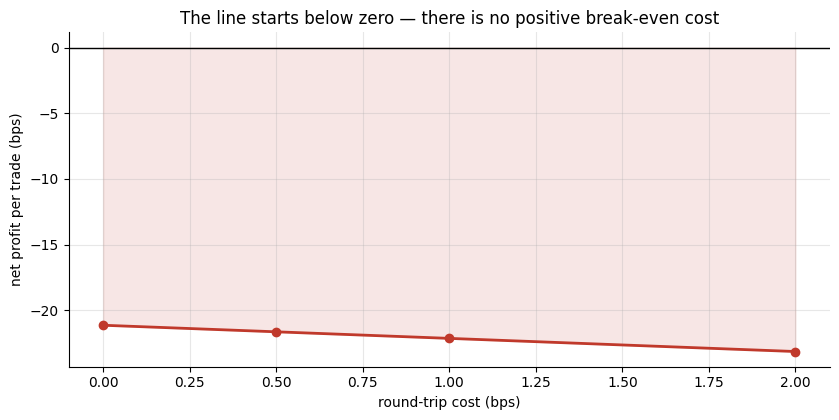

The gross edge is negative — costs are not the issue, the signal is.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pool(hold=5, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [-33.11, -33.61, -34.11, -35.11]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('The line starts below zero — there is no positive break-even cost')
plt.tight_layout(); plt.show()
print('The gross edge is negative — costs are not the issue, the signal is.')

## 7 · Going further

- **The positive control.** The companion notebook shows a synthetic tape: when we *plant* genuine mean-reversion in the data, CCI does find it. The rule is correctly built — the real market just has the wrong character for it.
- **Williams %R.** A closely related oscillator in the same mean-reversion family, tested in [Study 127](../../127-williams-r/) — same result.
- **The CCI as a momentum signal?** Some sources *fade* the rule — buy overbought, short oversold — treating CCI extremes as continuation signals rather than reversal signals. The 1-day positive hint is not significant, but that variant is worth a fork.
- **Commodity futures.** Lambert's original domain. If you have commodity futures data, that is the on-domain test and might show a different answer.

*Think the oscillator works on a different asset or timeframe? Fork this, change the instrument or hold window, and show a fair-bet edge that clears the coin and passes HAC inference. That is the bar.*